In [1]:
import pandas as pd

df = pd.read_csv('senate_bills_all.csv')
df.head()

,congress_id,link,long_title,short_title,authors,date_filed,subjects
0,60488,https://ldr.senate.gov.ph/bills/senate-bill-no...,AN ACT FURTHER AMENDING SECTION 32 OF REPUBLIC...,AMENDING SEC. 32 OF R.A. NO. 8434 (NATIONAL IN...,"GATCHALIAN, WIN","September 8, 2023",Public school teachers; BENEFITS AND INCENTIVE...
1,60488,https://ldr.senate.gov.ph/bills/senate-bill-no...,AN ACT EXPANDING THE SERVICES OF THE PHILIPPIN...,"AMENDING P.D. NO. 1467, (CREATING THE PHILIPPI...","GO, CHRISTOPHER LAWRENCE T.","March 5, 2023",PHILIPPINE CROP INSURANCE CORPORATION
2,60488,https://ldr.senate.gov.ph/bills/senate-bill-no...,NaN,GRANTING FULL TAX BENEFITS TO GOVERNMENT PURCH...,"MARCOS, IMEE R.","May 15, 2023",CALAMITY/DISASTER; TAX EXEMPTION
3,60488,https://ldr.senate.gov.ph/bills/senate-bill-no...,AN ACT AUTHORIZING PUBLIC-PRIVATE PARTNERSHIPS...,PUBLIC -PRIVATE PARTNERSHIP ACT,"GATCHALIAN, WIN","December 4, 2023",PUBLIC-PRIVATE PARTNERSHIP (PPP) PROJECTS
4,60488,https://ldr.senate.gov.ph/bills/senate-bill-no...,NaN,GOVERNMENT FINANCIAL INSTITUTIONS UNIFIED INIT...,"VILLANUEVA, JOEL","September 1, 2023",GOVERNMENT FINANCIAL INSTITUTIONS; ECONOMIC RE...


In [2]:
df.shape

(13894, 7)

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['long_title'].fillna(''))
nmf = NMF(n_components=5, random_state=42)
topics = nmf.fit_transform(X)

## LLM

In [32]:
from transformers import pipeline

qa = pipeline("question-answering", model="distilbert-base-cased-distilled-squad")


text = " ".join(
    df[['short_title', 'authors']]
    .dropna()
    .astype(str)
    .agg(" ".join, axis=1)   # join per row
)
qa({'context': text, 'question': "Which author has proposed the most bills on taxation?"})

Device set to use mps:0
/opt/miniconda3/envs/jbook/lib/python3.10/site-packages/transformers/pipelines/question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


{'score': 37.01583728232072,
 'start': 680266,
 'end': 680282,
 'answer': 'Manuel B. Villar'}

In [ ]:
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['long_title'].tolist(), convert_to_tensor=True)
query_emb = model.encode("tax policy", convert_to_tensor=True)
results = util.semantic_search(query_emb, embeddings, top_k=5)

## feature engineering

In [3]:
import pandas as pd
import numpy as np
import re

congress_dict = {
    13: 46,
    14: 47,
    15: 48,
    16: 240,
    17: 53,
    18: 220,
    19: 60488,
    20: 68805,
}
# reverse lookup: congress_id -> congress_number
id_to_number = {v: k for k, v in congress_dict.items()}

theme_keywords = {
    "Health": ["hospital", "medical", "nurse", "health", "care", "pharmacy", "vaccine"],
    "Education": ["school", "student", "teacher", "university", "education", "academy", "learning"],
    "Environment": ["environment", "reforestation", "wildlife", "forest", "climate", "renewable", "water"],
    "Transport": ["road", "transport", "vehicle", "motorcycle", "traffic", "highway", "public", "commute"],
    "Governance": ["government", "department", "administrative", "policy", "bureau", "regulation", "law"],
    "Economy": ["business", "industry", "commerce", "economic", "tax", "labor", "employment"],
    "Disaster/Resilience": ["disaster", "risk", "emergency", "evacuation", "safety", "protection", "calamity"],
}

# --- helper functions (adapted for Senate bills) ---

def extract_clean_words(text):
    """Return lowercase alphabetic words of length >=2 from text."""
    text = str(text).lower()
    return re.findall(r'\b[a-z]{2,}\b', text)

def assign_themes(title):
    """Assign themes to a bill title based on keywords."""
    title_words = extract_clean_words(title)
    matched = {theme for theme, kws in theme_keywords.items() if any(w in kws for w in title_words)}
    return tuple(sorted(matched)) if matched else ("Other",)

def parse_bill_from_link(link):
    """Extract bill type and number from LDR Senate bill URL."""
    # Example: .../senate-bill-no-2398-19th-congress
    match = re.search(r'/(senate|house)-bill-no-(\d+)-(\d+)[a-z]{2}-congress', str(link))
    if match:
        res_type = "SB" if match.group(1) == "senate" else "HB"
        res_number = int(match.group(2))
        congress_number = int(match.group(3))
        return res_type, res_number, congress_number
    return None, None, None

def parse_date(date_str):
    """Parse filing date into datetime."""
    return pd.to_datetime(date_str, errors='coerce')

# --- feature engineering pipeline ---

def engineer_features(df):
    df["congress_number"] = df["congress_id"].map({v: k for k, v in congress_dict.items()})
    
    # Themes
    df['theme'] = df['long_title'].fillna(df['short_title']).apply(assign_themes)
    df['primary_theme'] = df['theme'].apply(lambda x: x[0] if isinstance(x, tuple) else "Other")

    # Bill type and number from link
    df['res_type'], df['res_number'], df['congress_number_from_link'] = zip(*df['link'].map(parse_bill_from_link))

    # Filing date
    df['date_filed'] = df['date_filed'].apply(parse_date)
    df['year_filed'] = df['date_filed'].dt.year.astype("Int64")

    # Bill age in days
    today = pd.Timestamp.today()
    df['bill_age_days'] = (today - df['date_filed']).dt.days

    # Number of authors
    df['num_authors'] = df['authors'].apply(lambda x: len(str(x).split(";")) if pd.notna(x) else 0)

    return df

In [4]:
df2 = engineer_features(df)
df2['link'] = df2['link'].apply(lambda x: f'<a href="{x}" target="_blank">{x}</a>' if x else "")
df2.head()

,congress_id,link,long_title,short_title,authors,date_filed,subjects,congress_number,theme,primary_theme,res_type,res_number,congress_number_from_link,year_filed,bill_age_days,num_authors
0,60488,"<a href=""https://ldr.senate.gov.ph/bills/senat...",AN ACT FURTHER AMENDING SECTION 32 OF REPUBLIC...,AMENDING SEC. 32 OF R.A. NO. 8434 (NATIONAL IN...,"GATCHALIAN, WIN",2023-09-08,Public school teachers; BENEFITS AND INCENTIVE...,19,"(Other,)",Other,SB,2398,19,2023,752.0,1
1,60488,"<a href=""https://ldr.senate.gov.ph/bills/senat...",AN ACT EXPANDING THE SERVICES OF THE PHILIPPIN...,"AMENDING P.D. NO. 1467, (CREATING THE PHILIPPI...","GO, CHRISTOPHER LAWRENCE T.",2023-03-05,PHILIPPINE CROP INSURANCE CORPORATION,19,"(Other,)",Other,SB,2118,19,2023,939.0,1
2,60488,"<a href=""https://ldr.senate.gov.ph/bills/senat...",NaN,GRANTING FULL TAX BENEFITS TO GOVERNMENT PURCH...,"MARCOS, IMEE R.",2023-05-15,CALAMITY/DISASTER; TAX EXEMPTION,19,"(Disaster/Resilience, Economy, Governance)",Disaster/Resilience,SB,2182,19,2023,868.0,1
3,60488,"<a href=""https://ldr.senate.gov.ph/bills/senat...",AN ACT AUTHORIZING PUBLIC-PRIVATE PARTNERSHIPS...,PUBLIC -PRIVATE PARTNERSHIP ACT,"GATCHALIAN, WIN",2023-12-04,PUBLIC-PRIVATE PARTNERSHIP (PPP) PROJECTS,19,"(Transport,)",Transport,SB,2068,19,2023,665.0,1
4,60488,"<a href=""https://ldr.senate.gov.ph/bills/senat...",NaN,GOVERNMENT FINANCIAL INSTITUTIONS UNIFIED INIT...,"VILLANUEVA, JOEL",2023-09-01,GOVERNMENT FINANCIAL INSTITUTIONS; ECONOMIC RE...,19,"(Economy, Governance)",Economy,SB,1640,19,2023,759.0,1


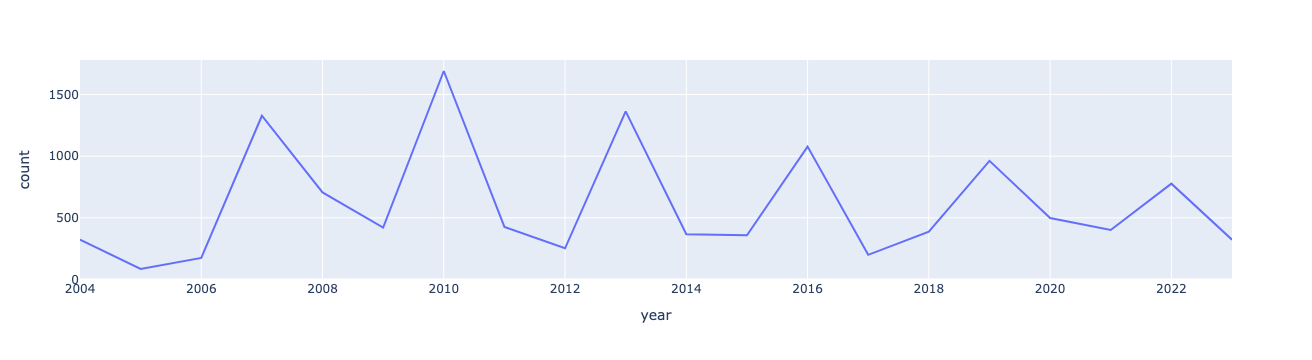

In [22]:
import plotly.express as px

df['year'] = pd.to_datetime(df['date_filed']).dt.year
fig = px.line(df.groupby('year').size().reset_index(name='count'), x='year', y='count')
fig.show()

In [23]:
import networkx as nx
G = nx.Graph()
for _, row in df.iterrows():
    authors = row['authors'].split('; ')
    subjects = row['subjects'].split('; ')
    for author in authors:
        for subject in subjects:
            G.add_edge(author, subject)

AttributeError: 'float' object has no attribute 'split'

In [15]:
import itables

# itables.options.column_filters = True  
# itables.init_notebook_mode()

dt_options = {
    "allow_html": True,
    "maxBytes": "1MB",
    "pageLength": 10,
    "scrollX": False,
    "autoWidth": False,
    "column_filters": "top",
    # "style": "width:100%",
}

cols = ['congress_number','short_title','authors','date_filed','link','long_title']
itables.show(df2[cols], **dt_options)

Loading ITables v2.5.2 from the internet... (need help?)


In [9]:
from pathlib import Path

# Save interactive HTML table
html_str = itables.to_html_datatable(df2[cols], **dt_options)
Path("senate_bills_interactive.html").write_text(html_str, encoding="utf-8");

In [18]:
subjects = (
    df['subjects']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .str.title()
)

# Count frequencies
subject_counts = subjects.value_counts().reset_index()
subject_counts.head(10)

,subjects,count
0,National Internal Revenue Code (Nirc),222
1,Amendments),209
2,Local Government Code (R.A. No. 7160),147
3,Local Government Units (Lgus),134
4,Philippine National Police (Pnp),122
5,Armed Forces Of The Philippines (Afp),114
6,Teachers,109
7,Revised Penal Code (R.A. No. 3815),103
8,Students,96
9,Children/Child Care,96


In [19]:
import itables

itables.init_notebook_mode()

dt_options = {
    "allow_html": True,
    # "maxBytes": "1MB",
    "pageLength": 10,
    "scrollX": True,
    "autoWidth": False,
}

cols = ['congress_number','short_title','authors','date_filed','link','long_title']
itables.show(subject_counts, **dt_options)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


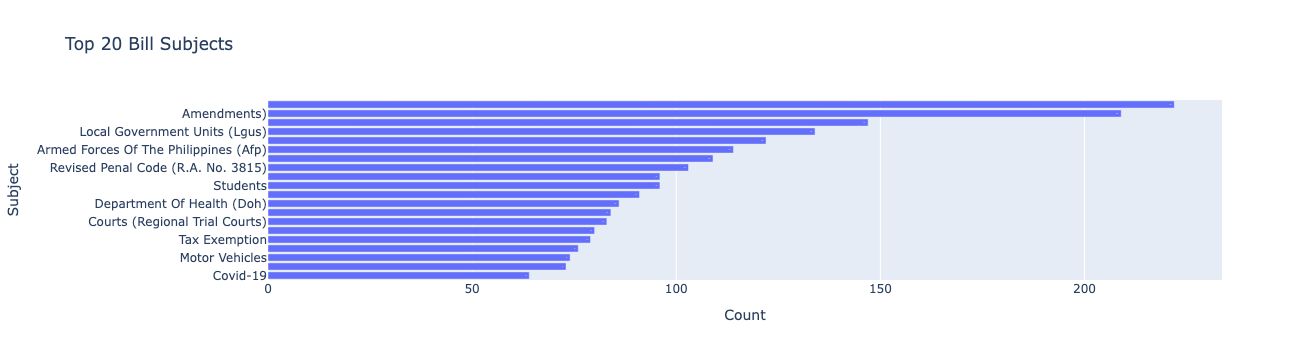

In [16]:
import pandas as pd
import plotly.express as px

def plot_subject_distribution(df):
    # Split subjects into rows
    subjects = (
        df['subjects']
        .dropna()
        .str.split(';')
        .explode()
        .str.strip()
        .str.title()
    )
    
    # Count frequencies
    subject_counts = subjects.value_counts().reset_index()
    subject_counts.columns = ['Subject', 'Count']
    
    # Plot
    fig = px.bar(
        subject_counts.sort_values('Count', ascending=False).head(20),
        x='Count',
        y='Subject',
        orientation='h',
        title="Top 20 Bill Subjects",
        text='Count'
    )
    fig.update_layout(yaxis={'categoryorder':'total ascending'})
    fig.show()

# Example usage:
plot_subject_distribution(df)

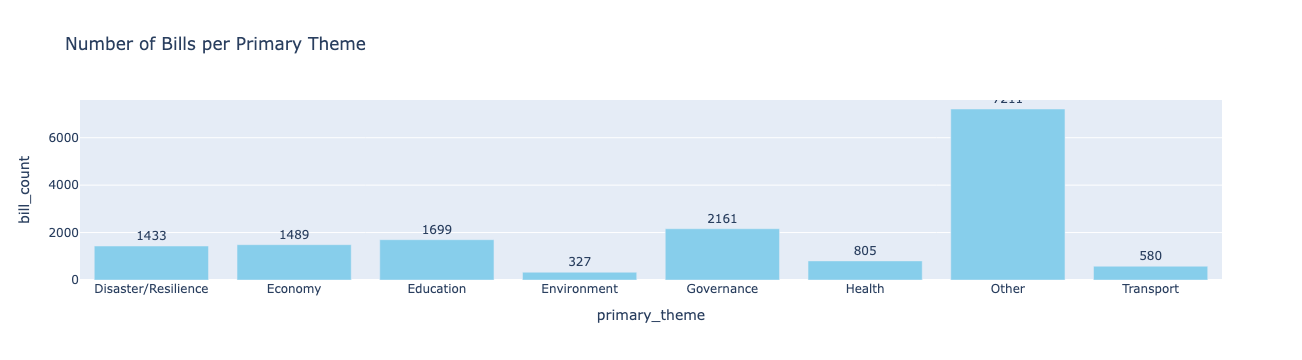

In [20]:
import plotly.express as px

fig_theme = px.bar(
    df.explode('theme').groupby('primary_theme').size().reset_index(name='bill_count'),
    x='primary_theme',
    y='bill_count',
    text='bill_count',
    title='Number of Bills per Primary Theme',
)
fig_theme.update_traces(marker_color='skyblue', textposition='outside')
fig_theme.show()

In [21]:
d = df.authors.value_counts()
d.head(10)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [30]:
top10 = df.authors.value_counts().head(10)
g = df.groupby(by='authors')
for author in top10.index:
    d = g.get_group(author)
    print(author)
    print(d.explode('theme').groupby('primary_theme').size().sort_values(ascending=False))

Miriam Defensor Santiago
primary_theme
Other                  1208
Education               280
Governance              253
Disaster/Resilience     235
Economy                 149
Health                  136
Transport                86
Environment              53
dtype: int64
ESTRADA, JINGGOY E.
primary_theme
Other                  659
Economy                225
Governance             223
Disaster/Resilience    169
Education              147
Health                  65
Transport               65
Environment             36
dtype: int64
REVILLA JR., RAMON BONG
primary_theme
Other                  410
Governance             120
Disaster/Resilience    109
Education              105
Economy                 68
Health                  36
Transport               32
Environment              9
dtype: int64
Antonio F. Trillanes IV
primary_theme
Other                  399
Governance             153
Disaster/Resilience     95
Education               80
Economy                 35
Health               